# Chapter 7: Ensemble Learning and Random Forests

## Overview

**Ensemble Learning** is a powerful machine learning technique that combines multiple predictors (models) to create a more robust and accurate model than any individual predictor alone. The key idea is the "wisdom of the crowd" - aggregating predictions from multiple models often yields better results than relying on a single expert model.

In this notebook, we'll explore:
1. Voting Classifiers (Hard and Soft)
2. Bagging and Pasting
3. Random Forests and Extra-Trees
4. Boosting (AdaBoost and Gradient Boosting)
5. Stacking

Let's start by importing the necessary libraries and preparing our data!

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Preparing the Dataset

We'll use the **make_moons** dataset, which creates two interleaving half circles. This is a good dataset for demonstrating ensemble methods because it's not linearly separable and presents a challenge for simple classifiers.

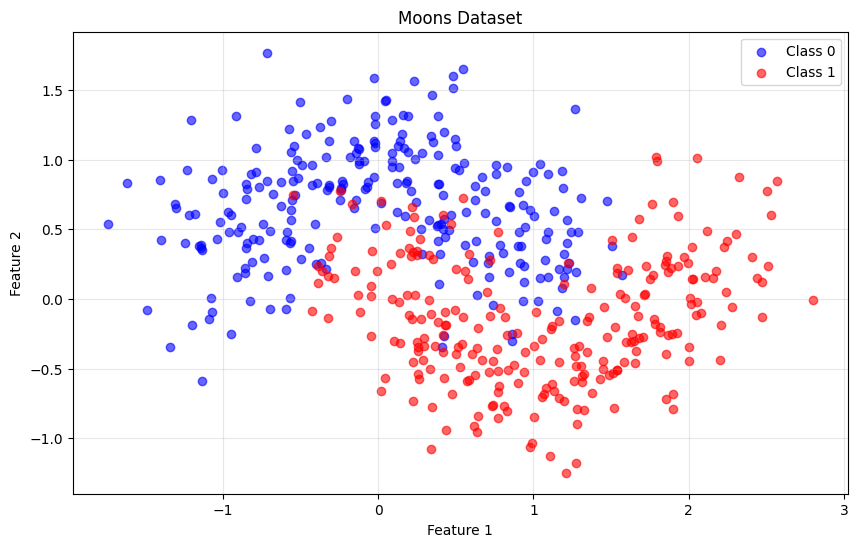

Training set size: 400
Test set size: 100


In [2]:
# Generate the moons dataset
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], c='blue', label='Class 0', alpha=0.6)
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], c='red', label='Class 1', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Moons Dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

## 1. Voting Classifiers

### What is a Voting Classifier?

A **Voting Classifier** aggregates predictions from multiple different classifiers and selects the class that gets the most votes. There are two types:

- **Hard Voting**: Each classifier votes for a class, and the majority wins
- **Soft Voting**: Each classifier provides probability estimates, and we average them

### Why Does It Work?

Even if each classifier is a **weak learner** (only slightly better than random guessing), the ensemble can be a **strong learner** with high accuracy. This is based on the **law of large numbers**: if you have many classifiers that are slightly better than random (e.g., 51% accuracy), their combined prediction can be much more accurate (e.g., 75%).

### Key Requirement

The classifiers should be **as independent as possible** - they should make different types of errors. One way to achieve this is by using very different training algorithms.

### Hard Voting Classifier Implementation

Let's create an ensemble of three different classifiers:
1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)

In [3]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Create individual classifiers
log_clf = LogisticRegression(random_state=42, max_iter=1000)
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
svm_clf = SVC(gamma='auto', random_state=42)

# Create a hard voting classifier
voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
    voting='hard'
)

print("Hard Voting Classifier created!")
print("\nTraining individual classifiers and the voting ensemble...")

Hard Voting Classifier created!

Training individual classifiers and the voting ensemble...


In [4]:
# Train and evaluate each classifier
print("\n" + "="*60)
print("HARD VOTING CLASSIFIER RESULTS")
print("="*60)

for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{clf.__class__.__name__:25s}: {accuracy:.4f}")

print("="*60)
print("\nNotice how the VotingClassifier often outperforms individual classifiers!")


HARD VOTING CLASSIFIER RESULTS
LogisticRegression       : 0.8500
RandomForestClassifier   : 0.8800
SVC                      : 0.8700
VotingClassifier         : 0.8700

Notice how the VotingClassifier often outperforms individual classifiers!
VotingClassifier         : 0.8700

Notice how the VotingClassifier often outperforms individual classifiers!


### Soft Voting Classifier Implementation

**Soft voting** typically achieves higher performance than hard voting because it gives more weight to highly confident predictions. Instead of just counting votes, it averages the probability estimates from all classifiers.

**Important**: All classifiers must have a `predict_proba()` method. For SVC, we need to set `probability=True`.

In [5]:
# Create individual classifiers with probability support
log_clf = LogisticRegression(random_state=42, max_iter=1000)
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
svm_clf = SVC(gamma='auto', probability=True, random_state=42)  # Enable probability estimates

# Create a soft voting classifier
voting_clf_soft = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
    voting='soft'  # Changed from 'hard' to 'soft'
)

print("Soft Voting Classifier created!")
print("\nTraining classifiers...")

Soft Voting Classifier created!

Training classifiers...


In [6]:
# Train and evaluate with soft voting
print("\n" + "="*60)
print("SOFT VOTING CLASSIFIER RESULTS")
print("="*60)

for clf in (log_clf, rnd_clf, svm_clf, voting_clf_soft):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{clf.__class__.__name__:25s}: {accuracy:.4f}")

print("="*60)
print("\nSoft voting often performs even better than hard voting!")


SOFT VOTING CLASSIFIER RESULTS
LogisticRegression       : 0.8500
RandomForestClassifier   : 0.8800
SVC                      : 0.8700
VotingClassifier         : 0.8900

Soft voting often performs even better than hard voting!
VotingClassifier         : 0.8900

Soft voting often performs even better than hard voting!


## 2. Bagging and Pasting

### What are Bagging and Pasting?

Instead of using different training algorithms, we can use the **same algorithm** but train it on different random subsets of the training data:

- **Bagging** (Bootstrap Aggregating): Sampling **with replacement** - the same instance can be selected multiple times
- **Pasting**: Sampling **without replacement** - each instance can only be selected once per predictor

### Benefits

1. **Reduces variance** while maintaining similar bias
2. **Highly parallelizable** - predictors can be trained simultaneously
3. Predictions can also be made in parallel

### Bagging vs. Pasting

- **Bagging** introduces more diversity (higher bias but lower variance)
- Generally results in better models, which is why it's more popular

In [7]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Create a bagging classifier with Decision Trees
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(random_state=42),
    n_estimators=500,      # Number of predictors in the ensemble
    max_samples=100,       # Size of each sample
    bootstrap=True,        # True for bagging, False for pasting
    n_jobs=-1,             # Use all available CPU cores
    random_state=42
)

# Train the bagging classifier
bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)

# Compare with a single Decision Tree
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

print("\n" + "="*60)
print("BAGGING vs SINGLE DECISION TREE")
print("="*60)
print(f"Single Decision Tree Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Bagging Classifier Accuracy:   {accuracy_score(y_test, y_pred_bag):.4f}")
print("="*60)
print("\nBagging significantly improves performance by reducing variance!")


BAGGING vs SINGLE DECISION TREE
Single Decision Tree Accuracy: 0.8200
Bagging Classifier Accuracy:   0.9000

Bagging significantly improves performance by reducing variance!


### Out-of-Bag (OOB) Evaluation

With bagging, on average, only about **63% of training instances** are sampled for each predictor. The remaining **37%** are called **out-of-bag (OOB) instances**.

**Key Advantage**: These OOB instances can be used for evaluation without needing a separate validation set! Each predictor is evaluated using the instances it wasn't trained on.

In [8]:
# Create a bagging classifier with OOB evaluation
bag_clf_oob = BaggingClassifier(
    DecisionTreeClassifier(random_state=42),
    n_estimators=500,
    bootstrap=True,
    n_jobs=-1,
    oob_score=True,  # Enable OOB evaluation
    random_state=42
)

bag_clf_oob.fit(X_train, y_train)

print("\n" + "="*60)
print("OUT-OF-BAG (OOB) EVALUATION")
print("="*60)
print(f"OOB Score:       {bag_clf_oob.oob_score_:.4f}")

# Verify on test set
y_pred = bag_clf_oob.predict(X_test)
print(f"Test Set Score:  {accuracy_score(y_test, y_pred):.4f}")
print("="*60)
print("\nOOB score is a good estimate of test performance without using a validation set!")

# Show OOB decision function (probability estimates)
print(f"\nOOB Decision Function shape: {bag_clf_oob.oob_decision_function_.shape}")
print(f"First 5 OOB probability estimates:\n{bag_clf_oob.oob_decision_function_[:5]}")


OUT-OF-BAG (OOB) EVALUATION
OOB Score:       0.9100
Test Set Score:  0.8800

OOB score is a good estimate of test performance without using a validation set!

OOB Decision Function shape: (400, 2)
First 5 OOB probability estimates:
[[1.         0.        ]
 [0.         1.        ]
 [0.03157895 0.96842105]
 [0.95744681 0.04255319]
 [0.99386503 0.00613497]]


## 3. Random Forests

### What is a Random Forest?

A **Random Forest** is an ensemble of Decision Trees, typically trained via bagging. It's one of the most powerful and popular machine learning algorithms!

### Key Innovation

Instead of searching for the best feature among **all features** when splitting nodes, Random Forests search for the best feature among a **random subset of features**. This introduces extra randomness, trading higher bias for lower variance, which results in a better overall model.

### Implementation

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest classifier
rnd_clf = RandomForestClassifier(
    n_estimators=500,      # Number of trees
    max_leaf_nodes=16,     # Maximum leaf nodes per tree
    n_jobs=-1,             # Use all CPU cores
    random_state=42
)

rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)

print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER")
print("="*60)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("="*60)


RANDOM FOREST CLASSIFIER
Random Forest Accuracy: 0.8900


### Feature Importance

One of the most valuable features of Random Forests is that they can measure **feature importance**. This tells us which features are most useful for making predictions.

The importance is calculated by looking at how much tree nodes using that feature reduce impurity (e.g., Gini impurity or entropy) on average across all trees.

Let's demonstrate this with the Iris dataset:


FEATURE IMPORTANCE (Iris Dataset)
sepal length (cm)   : 0.1125
sepal width (cm)    : 0.0231
petal length (cm)   : 0.4410
petal width (cm)    : 0.4234


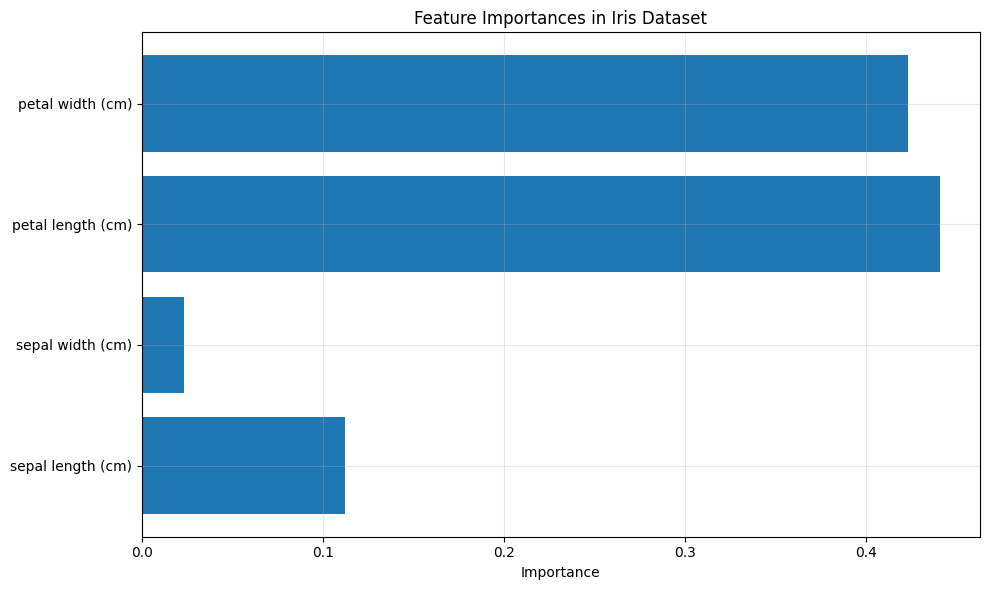


Petal features are most important for classifying Iris species!


In [10]:
# Load the Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Train a Random Forest on Iris
rnd_clf_iris = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf_iris.fit(X_iris, y_iris)

# Display feature importances
print("\n" + "="*60)
print("FEATURE IMPORTANCE (Iris Dataset)")
print("="*60)

for name, score in zip(iris.feature_names, rnd_clf_iris.feature_importances_):
    print(f"{name:20s}: {score:.4f}")

print("="*60)

# Visualize feature importances
plt.figure(figsize=(10, 6))
plt.barh(iris.feature_names, rnd_clf_iris.feature_importances_)
plt.xlabel('Importance')
plt.title('Feature Importances in Iris Dataset')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPetal features are most important for classifying Iris species!")

### Extra-Trees (Extremely Randomized Trees)

**Extra-Trees** make the forest even more random by using **random thresholds** for each feature rather than searching for the best possible thresholds.

**Advantages:**
- Much faster to train than regular Random Forests
- Trades more bias for lower variance

**When to use:** Use cross-validation to determine whether Random Forest or Extra-Trees performs better for your specific problem.

In [11]:
from sklearn.ensemble import ExtraTreesClassifier
import time

# Create an Extra-Trees classifier
extra_trees_clf = ExtraTreesClassifier(
    n_estimators=500,
    max_leaf_nodes=16,
    n_jobs=-1,
    random_state=42
)

# Time the training
start_time = time.time()
extra_trees_clf.fit(X_train, y_train)
extra_trees_time = time.time() - start_time

# Time Random Forest for comparison
rnd_clf_time = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1, random_state=42)
start_time = time.time()
rnd_clf_time.fit(X_train, y_train)
rf_time = time.time() - start_time

# Compare results
y_pred_extra = extra_trees_clf.predict(X_test)

print("\n" + "="*60)
print("EXTRA-TREES vs RANDOM FOREST")
print("="*60)
print(f"Random Forest:")
print(f"  - Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  - Training time: {rf_time:.3f} seconds")
print(f"\nExtra-Trees:")
print(f"  - Accuracy: {accuracy_score(y_test, y_pred_extra):.4f}")
print(f"  - Training time: {extra_trees_time:.3f} seconds")
print("="*60)
print("\nExtra-Trees is typically faster to train!")


EXTRA-TREES vs RANDOM FOREST
Random Forest:
  - Accuracy: 0.8900
  - Training time: 0.605 seconds

Extra-Trees:
  - Accuracy: 0.8900
  - Training time: 0.482 seconds

Extra-Trees is typically faster to train!


## 4. Boosting

### What is Boosting?

**Boosting** is a technique that combines several weak learners into a strong learner by training predictors **sequentially**, each trying to correct its predecessor.

Unlike bagging/pasting where predictors are trained in parallel, boosting trains them one after another, with each new predictor focusing on the mistakes of the previous ones.

We'll explore two popular boosting methods:
1. **AdaBoost** (Adaptive Boosting)
2. **Gradient Boosting**

### AdaBoost (Adaptive Boosting)

**How AdaBoost Works:**

1. Train a base classifier on the training set
2. Increase the weights of misclassified instances
3. Train a second classifier using the updated weights
4. Repeat: make predictions, update weights, train next classifier
5. Stop when the desired number of predictors is reached or a perfect predictor is found

**Key Idea**: The algorithm pays more attention to training instances that previous predictors got wrong.

**Mathematical Components:**

- **Weighted Error Rate**: $r_j = \frac{\sum_{i=1, \hat{y}_j^{(i)} \neq y^{(i)}}^{m} w^{(i)}}{\sum_{i=1}^{m} w^{(i)}}$

- **Predictor Weight**: $\alpha_j = \eta \log \frac{1 - r_j}{r_j}$

- **Instance Weight Update**: Misclassified instances get weight $w^{(i)} \exp(\alpha_j)$

In [18]:
from sklearn.ensemble import AdaBoostClassifier

# Create an AdaBoost classifier
# Using Decision Stumps (Decision Trees with max_depth=1) as base estimators
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),  # Decision Stump
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_test)

print("\n" + "="*60)
print("ADABOOST CLASSIFIER")
print("="*60)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")
print("="*60)
print("\nAdaBoost combines weak learners (Decision Stumps) into a strong classifier!")


ADABOOST CLASSIFIER
AdaBoost Accuracy: 0.8900

AdaBoost combines weak learners (Decision Stumps) into a strong classifier!



ADABOOST LEARNING CURVE
n_estimators=  1: Accuracy = 0.8400
n_estimators= 10: Accuracy = 0.8100
n_estimators= 50: Accuracy = 0.8900
n_estimators=100: Accuracy = 0.8900
n_estimators=100: Accuracy = 0.8900
n_estimators=200: Accuracy = 0.8900
n_estimators=200: Accuracy = 0.8900


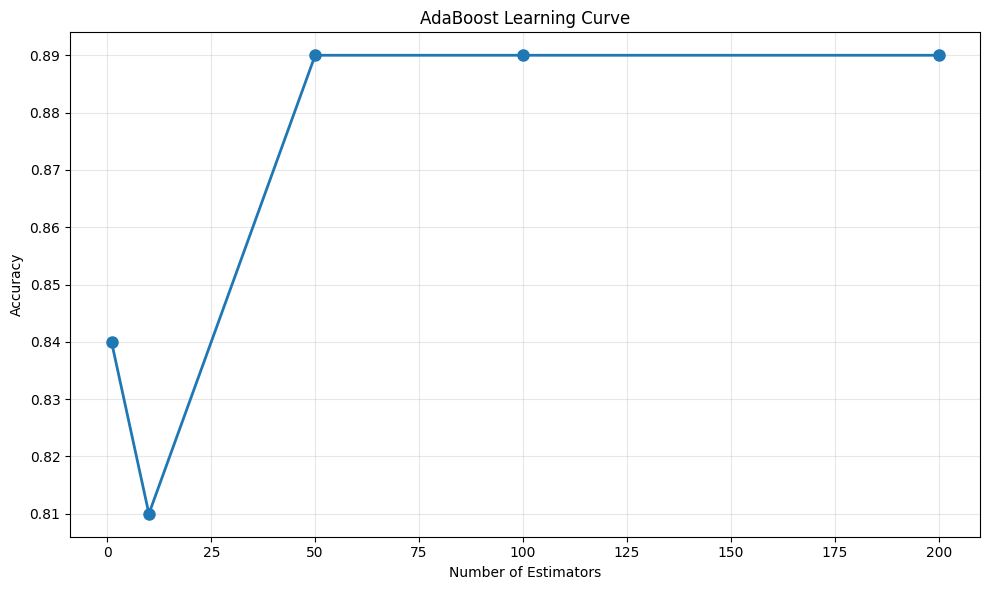


Accuracy improves as we add more weak learners!


In [19]:
# Compare AdaBoost with different numbers of estimators
estimator_counts = [1, 10, 50, 100, 200]
accuracies = []

print("\n" + "="*60)
print("ADABOOST LEARNING CURVE")
print("="*60)

for n_est in estimator_counts:
    ada_temp = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=n_est,
        learning_rate=0.5,
        random_state=42
    )
    ada_temp.fit(X_train, y_train)
    y_pred_temp = ada_temp.predict(X_test)
    acc = accuracy_score(y_test, y_pred_temp)
    accuracies.append(acc)
    print(f"n_estimators={n_est:3d}: Accuracy = {acc:.4f}")

print("="*60)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(estimator_counts, accuracies, 'o-', linewidth=2, markersize=8)
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('AdaBoost Learning Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAccuracy improves as we add more weak learners!")

### Gradient Boosting

**How Gradient Boosting Works:**

Instead of tweaking instance weights like AdaBoost, Gradient Boosting fits new predictors to the **residual errors** made by the previous predictor.

**Process:**
1. Train first predictor
2. Calculate residuals (errors)
3. Train second predictor on residuals
4. Calculate new residuals
5. Repeat until desired number of predictors

Let's demonstrate with a regression problem:

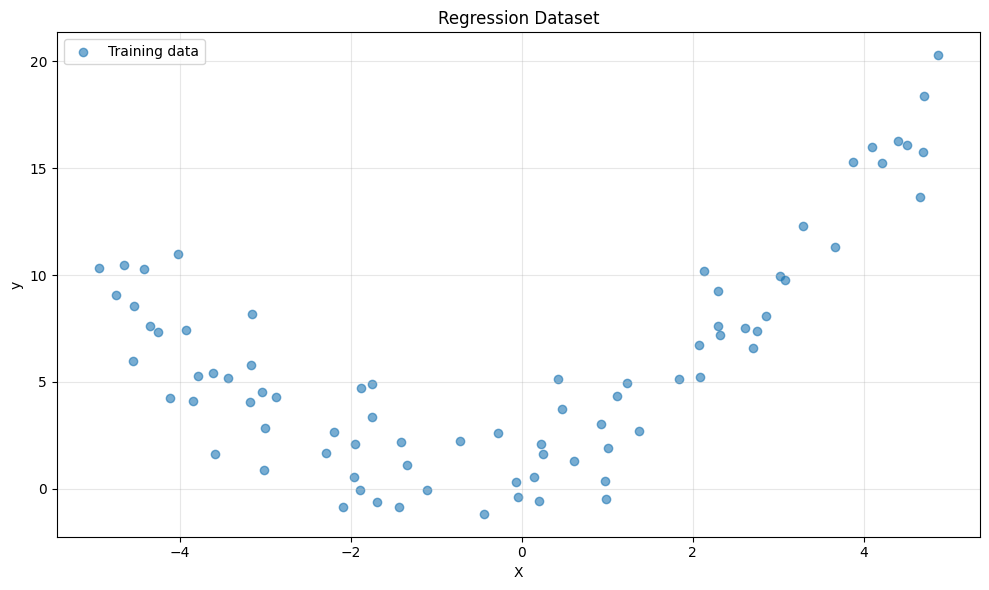

Dataset created for demonstrating Gradient Boosting!


In [20]:
# Generate a simple regression dataset
np.random.seed(42)
X_reg = np.random.rand(100, 1) * 10 - 5
y_reg = 0.5 * X_reg**2 + X_reg + 2 + np.random.randn(100, 1) * 2
y_reg = y_reg.ravel()

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X_reg_train, y_reg_train, alpha=0.6, label='Training data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Regression Dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Dataset created for demonstrating Gradient Boosting!")

In [21]:
from sklearn.tree import DecisionTreeRegressor

# Manual implementation to understand the concept
print("\n" + "="*60)
print("GRADIENT BOOSTING - MANUAL IMPLEMENTATION")
print("="*60)

# Train first predictor
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X_reg_train, y_reg_train)
y_pred_1 = tree_reg1.predict(X_reg_train)
mse_1 = mean_squared_error(y_reg_train, y_pred_1)
print(f"\nTree 1 MSE: {mse_1:.4f}")

# Train second predictor on residual errors
y2 = y_reg_train - tree_reg1.predict(X_reg_train)
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg2.fit(X_reg_train, y2)
y_pred_2 = tree_reg1.predict(X_reg_train) + tree_reg2.predict(X_reg_train)
mse_2 = mean_squared_error(y_reg_train, y_pred_2)
print(f"Tree 1+2 MSE: {mse_2:.4f}")

# Train third predictor on residual errors of second
y3 = y2 - tree_reg2.predict(X_reg_train)
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg3.fit(X_reg_train, y3)
y_pred_3 = y_pred_2 + tree_reg3.predict(X_reg_train)
mse_3 = mean_squared_error(y_reg_train, y_pred_3)
print(f"Tree 1+2+3 MSE: {mse_3:.4f}")

print("="*60)
print("\nError decreases as we add more trees that correct previous mistakes!")

# Make predictions on test set
y_pred_test = sum(tree.predict(X_reg_test) for tree in (tree_reg1, tree_reg2, tree_reg3))
test_mse = mean_squared_error(y_reg_test, y_pred_test)
print(f"Test MSE: {test_mse:.4f}")


GRADIENT BOOSTING - MANUAL IMPLEMENTATION

Tree 1 MSE: 6.7587
Tree 1+2 MSE: 3.3956
Tree 1+2+3 MSE: 3.0575

Error decreases as we add more trees that correct previous mistakes!
Test MSE: 3.8426



GRADIENT BOOSTING REGRESSOR (Scikit-learn)
Test MSE: 3.1276


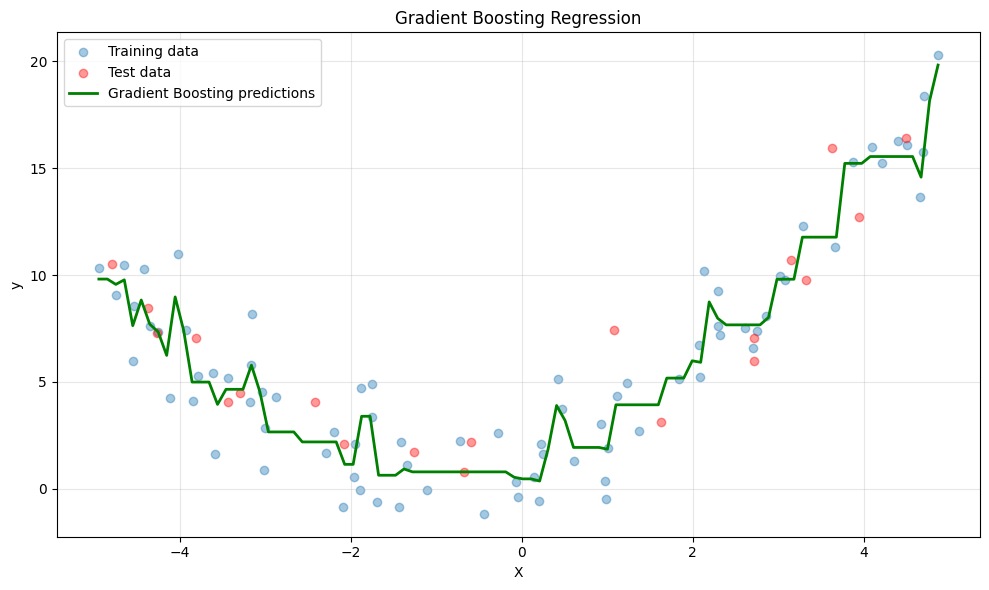

In [22]:
from sklearn.ensemble import GradientBoostingRegressor

# Using sklearn's GradientBoostingRegressor
gbrt = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gbrt.fit(X_reg_train, y_reg_train)
y_pred_gbrt = gbrt.predict(X_reg_test)

print("\n" + "="*60)
print("GRADIENT BOOSTING REGRESSOR (Scikit-learn)")
print("="*60)
print(f"Test MSE: {mean_squared_error(y_reg_test, y_pred_gbrt):.4f}")
print("="*60)

# Visualize predictions
X_plot = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
y_plot = gbrt.predict(X_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_reg_train, y_reg_train, alpha=0.4, label='Training data')
plt.scatter(X_reg_test, y_reg_test, alpha=0.4, color='red', label='Test data')
plt.plot(X_plot, y_plot, 'g-', linewidth=2, label='Gradient Boosting predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Gradient Boosting Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Learning Rate and Early Stopping

**Learning Rate (Shrinkage)**: A lower learning rate requires more trees but generally leads to better generalization. Each tree's contribution is scaled down by the learning rate.

**Early Stopping**: We can find the optimal number of trees by monitoring validation error and stopping when it starts increasing.


EARLY STOPPING
Optimal number of estimators: 113
Minimum validation MSE: 7.1057


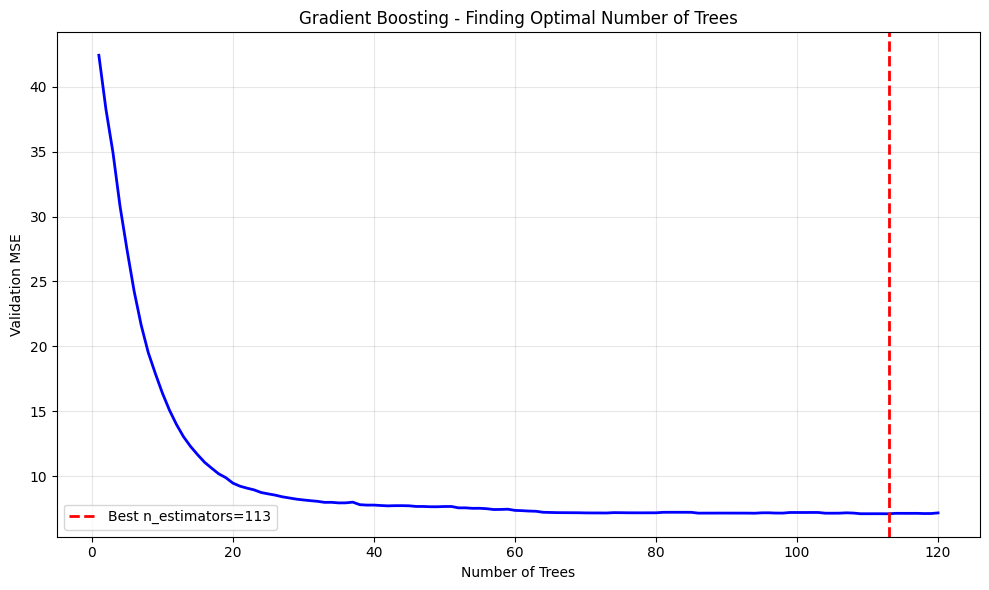


Final Test MSE with optimal estimators: 3.1255


In [23]:
# Split training data into train and validation
X_reg_train2, X_reg_val, y_reg_train2, y_reg_val = train_test_split(
    X_reg_train, y_reg_train, test_size=0.2, random_state=42
)

# Train with many estimators
gbrt_early = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=120,
    learning_rate=0.1,
    random_state=42
)

gbrt_early.fit(X_reg_train2, y_reg_train2)

# Calculate validation errors for each stage
errors = [mean_squared_error(y_reg_val, y_pred)
          for y_pred in gbrt_early.staged_predict(X_reg_val)]

# Find the best number of estimators
bst_n_estimators = np.argmin(errors) + 1

print("\n" + "="*60)
print("EARLY STOPPING")
print("="*60)
print(f"Optimal number of estimators: {bst_n_estimators}")
print(f"Minimum validation MSE: {min(errors):.4f}")
print("="*60)

# Plot validation error
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(errors) + 1), errors, 'b-', linewidth=2)
plt.axvline(bst_n_estimators, color='r', linestyle='--', linewidth=2, label=f'Best n_estimators={bst_n_estimators}')
plt.xlabel('Number of Trees')
plt.ylabel('Validation MSE')
plt.title('Gradient Boosting - Finding Optimal Number of Trees')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Train final model with optimal number of estimators
gbrt_best = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=bst_n_estimators,
    learning_rate=0.1,
    random_state=42
)

gbrt_best.fit(X_reg_train, y_reg_train)
y_pred_best = gbrt_best.predict(X_reg_test)
print(f"\nFinal Test MSE with optimal estimators: {mean_squared_error(y_reg_test, y_pred_best):.4f}")

### Gradient Boosting for Classification

Let's apply Gradient Boosting to our moons classification problem:

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

# Create a Gradient Boosting classifier
gb_clf = GradientBoostingClassifier(
    max_depth=2,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)

print("\n" + "="*60)
print("GRADIENT BOOSTING CLASSIFIER")
print("="*60)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print("="*60)


GRADIENT BOOSTING CLASSIFIER
Gradient Boosting Accuracy: 0.9000


### Random Patches and Random Subspaces

The `BaggingClassifier` supports sampling not just training instances, but also features!

**Two methods:**
- **Random Patches**: Sampling both training instances AND features
- **Random Subspaces**: Keeping all instances but sampling features

**Parameters:**
- `max_features`: number of features to sample
- `bootstrap_features`: whether to sample with replacement (True) or without (False)

Let's demonstrate both methods:

In [25]:
# Random Patches method: sampling both instances AND features
random_patches_clf = BaggingClassifier(
    DecisionTreeClassifier(random_state=42),
    n_estimators=500,
    max_samples=100,       # Sample 100 instances
    bootstrap=True,        # With replacement
    max_features=1,        # Sample 1 feature (out of 2)
    bootstrap_features=True,  # With replacement
    n_jobs=-1,
    random_state=42
)

random_patches_clf.fit(X_train, y_train)
y_pred_patches = random_patches_clf.predict(X_test)

# Random Subspaces method: keeping all instances but sampling features
random_subspaces_clf = BaggingClassifier(
    DecisionTreeClassifier(random_state=42),
    n_estimators=500,
    max_samples=1.0,       # Use all instances
    bootstrap=False,       # No replacement (use all)
    max_features=1,        # Sample 1 feature
    bootstrap_features=True,  # With replacement
    n_jobs=-1,
    random_state=42
)

random_subspaces_clf.fit(X_train, y_train)
y_pred_subspaces = random_subspaces_clf.predict(X_test)

print("\n" + "="*60)
print("RANDOM PATCHES vs RANDOM SUBSPACES")
print("="*60)
print(f"Random Patches Accuracy:    {accuracy_score(y_test, y_pred_patches):.4f}")
print(f"Random Subspaces Accuracy:  {accuracy_score(y_test, y_pred_subspaces):.4f}")
print(f"Standard Bagging Accuracy:  {accuracy_score(y_test, y_pred_bag):.4f}")
print("="*60)
print("\nFeature sampling adds extra diversity to the ensemble!")


RANDOM PATCHES vs RANDOM SUBSPACES
Random Patches Accuracy:    0.8400
Random Subspaces Accuracy:  0.6400
Standard Bagging Accuracy:  0.9000

Feature sampling adds extra diversity to the ensemble!


### Early Stopping with warm_start

An alternative approach to early stopping uses the `warm_start=True` parameter, which allows incremental training. This approach trains trees one at a time and stops when validation error stops improving.

In [26]:
# Early stopping with warm_start
gbrt_warm = GradientBoostingRegressor(max_depth=2, warm_start=True, random_state=42)

min_val_error = float("inf")
error_going_up = 0

print("\n" + "="*60)
print("EARLY STOPPING WITH warm_start")
print("="*60)

for n_estimators in range(1, 120):
    gbrt_warm.n_estimators = n_estimators
    gbrt_warm.fit(X_reg_train2, y_reg_train2)
    y_pred = gbrt_warm.predict(X_reg_val)
    val_error = mean_squared_error(y_reg_val, y_pred)
    
    if val_error < min_val_error:
        min_val_error = val_error
        error_going_up = 0
    else:
        error_going_up += 1
        if error_going_up == 5:
            print(f"Early stopping at n_estimators={n_estimators}")
            print(f"Minimum validation error: {min_val_error:.4f}")
            break

print("="*60)
print(f"\nFinal model has {gbrt_warm.n_estimators} estimators")

# Test on test set
y_pred_warm = gbrt_warm.predict(X_reg_test)
print(f"Test MSE: {mean_squared_error(y_reg_test, y_pred_warm):.4f}")


EARLY STOPPING WITH warm_start
Early stopping at n_estimators=78
Minimum validation error: 7.1669

Final model has 78 estimators
Test MSE: 2.4364


### Stochastic Gradient Boosting

The `subsample` hyperparameter specifies the fraction of training instances to use for each tree. This technique is called **Stochastic Gradient Boosting**.

**Benefits:**
- Trades higher bias for lower variance
- Speeds up training considerably
- Often improves generalization

**Typical values**: 0.25 to 0.5 (use 25% to 50% of instances per tree)

In [27]:
# Stochastic Gradient Boosting with subsample
gbrt_stochastic = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=100,
    learning_rate=0.1,
    subsample=0.25,  # Each tree trained on 25% of instances
    random_state=42
)

gbrt_stochastic.fit(X_reg_train, y_reg_train)
y_pred_stochastic = gbrt_stochastic.predict(X_reg_test)

# Compare with regular Gradient Boosting
print("\n" + "="*60)
print("STOCHASTIC GRADIENT BOOSTING")
print("="*60)
print(f"Regular Gradient Boosting MSE:    {mean_squared_error(y_reg_test, y_pred_gbrt):.4f}")
print(f"Stochastic Gradient Boosting MSE: {mean_squared_error(y_reg_test, y_pred_stochastic):.4f}")
print("="*60)
print("\nStochastic GB trades some accuracy for faster training and better generalization!")


STOCHASTIC GRADIENT BOOSTING
Regular Gradient Boosting MSE:    3.1276
Stochastic Gradient Boosting MSE: 3.4086

Stochastic GB trades some accuracy for faster training and better generalization!


### XGBoost (Extreme Gradient Boosting)

**XGBoost** is an optimized implementation of Gradient Boosting that is:
- Extremely fast and scalable
- Highly portable (works on various platforms)
- Often a key component in winning ML competition solutions

**Features:**
- Supports automatic early stopping
- Provides built-in regularization
- Handles missing values automatically
- Can run on GPU

Let's install and use XGBoost:

In [28]:
# Install XGBoost if not already installed
try:
    import xgboost
    print("XGBoost is already installed!")
except ImportError:
    print("Installing XGBoost...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    import xgboost
    print("XGBoost installed successfully!")

# Basic XGBoost regression
xgb_reg = xgboost.XGBRegressor(random_state=42)
xgb_reg.fit(X_reg_train, y_reg_train)
y_pred_xgb = xgb_reg.predict(X_reg_test)

print("\n" + "="*60)
print("XGBOOST REGRESSOR")
print("="*60)
print(f"XGBoost MSE: {mean_squared_error(y_reg_test, y_pred_xgb):.4f}")
print("="*60)

XGBoost is already installed!

XGBOOST REGRESSOR
XGBoost MSE: 4.1321

XGBOOST REGRESSOR
XGBoost MSE: 4.1321


In [30]:
# XGBoost with automatic early stopping
xgb_reg_early = xgboost.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    early_stopping_rounds=2,  # Moved to constructor
    random_state=42
)

# Fit with early stopping
xgb_reg_early.fit(
    X_reg_train2, y_reg_train2,
    eval_set=[(X_reg_val, y_reg_val)],
    verbose=False
)

y_pred_xgb_early = xgb_reg_early.predict(X_reg_test)

print("\n" + "="*60)
print("XGBOOST WITH EARLY STOPPING")
print("="*60)
print(f"Best iteration: {xgb_reg_early.best_iteration}")
print(f"Test MSE: {mean_squared_error(y_reg_test, y_pred_xgb_early):.4f}")
print("="*60)
print("\nXGBoost automatically stops when validation error stops improving!")


XGBOOST WITH EARLY STOPPING
Best iteration: 102
Test MSE: 6.5144

XGBoost automatically stops when validation error stops improving!


## 5. Stacking (Stacked Generalization)

### What is Stacking?

Instead of using simple functions (like voting or averaging) to aggregate predictions from multiple predictors, **stacking trains a model to perform the aggregation**. This final predictor is called a **blender** or **meta learner**.

### How Stacking Works

**Training Process:**

1. **Split training set** into two or three subsets
2. **Train first layer** of predictors on Subset 1
3. **Make predictions** on Subset 2 using first layer
4. **Create new training set** where features are the predictions from first layer, targets are original targets
5. **Train blender** (meta learner) on this new training set

**For multiple layers:**
- Subset 1: Train first layer
- Subset 2: Create training set for second layer (using first layer's predictions)
- Subset 3: Create training set for third layer (using second layer's predictions)

### Implementation

Scikit-Learn now has `StackingClassifier` and `StackingRegressor` (added in version 0.22)!

In [31]:
from sklearn.ensemble import StackingClassifier

# Create base (first layer) estimators
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('extra_trees', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('svm', SVC(gamma='auto', probability=True, random_state=42)),
    ('ada', AdaBoostClassifier(n_estimators=100, random_state=42))
]

# Create the stacking classifier with Logistic Regression as the blender
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(),
    cv=5  # Use 5-fold cross-validation to generate training data for the blender
)

print("Training Stacking Classifier...")
stacking_clf.fit(X_train, y_train)
y_pred_stacking = stacking_clf.predict(X_test)

print("\n" + "="*60)
print("STACKING CLASSIFIER")
print("="*60)
print(f"Stacking Accuracy: {accuracy_score(y_test, y_pred_stacking):.4f}")
print("="*60)
print("\nThe blender learns how to best combine the base models' predictions!")

Training Stacking Classifier...

STACKING CLASSIFIER
Stacking Accuracy: 0.9000

The blender learns how to best combine the base models' predictions!

STACKING CLASSIFIER
Stacking Accuracy: 0.9000

The blender learns how to best combine the base models' predictions!


In [32]:
# Compare stacking with individual models and voting
print("\n" + "="*60)
print("STACKING vs INDIVIDUAL MODELS vs VOTING")
print("="*60)

# Train individual models
for name, model in base_estimators:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name:15s}: {accuracy_score(y_test, y_pred):.4f}")

# Voting Classifier
voting_for_comparison = VotingClassifier(
    estimators=base_estimators,
    voting='soft'
)
voting_for_comparison.fit(X_train, y_train)
y_pred_voting = voting_for_comparison.predict(X_test)
print(f"{'Voting':15s}: {accuracy_score(y_test, y_pred_voting):.4f}")

# Stacking
print(f"{'Stacking':15s}: {accuracy_score(y_test, y_pred_stacking):.4f}")
print("="*60)
print("\nStacking often achieves the best performance by learning optimal weights!")


STACKING vs INDIVIDUAL MODELS vs VOTING
rf             : 0.8800
extra_trees    : 0.8800
svm            : 0.8700
extra_trees    : 0.8800
svm            : 0.8700
ada            : 0.8700
ada            : 0.8700
Voting         : 0.8800
Stacking       : 0.9000

Stacking often achieves the best performance by learning optimal weights!
Voting         : 0.8800
Stacking       : 0.9000

Stacking often achieves the best performance by learning optimal weights!


### Manual Stacking Implementation

Let's also implement stacking manually to understand how it works under the hood:

In [33]:
# Manual Stacking Implementation
print("\n" + "="*60)
print("MANUAL STACKING IMPLEMENTATION")
print("="*60)

# Step 1: Split training data into two subsets
X_train_l1, X_train_l2, y_train_l1, y_train_l2 = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42
)

# Step 2: Train first layer models on subset 1
first_layer_models = [
    RandomForestClassifier(n_estimators=100, random_state=42),
    ExtraTreesClassifier(n_estimators=100, random_state=42),
    SVC(gamma='auto', probability=True, random_state=42)
]

print("\nTraining first layer models...")
for model in first_layer_models:
    model.fit(X_train_l1, y_train_l1)

# Step 3: Make predictions on subset 2 (these become features for the blender)
print("Generating predictions for second layer...")
X_train_l2_stacked = np.column_stack([
    model.predict_proba(X_train_l2) for model in first_layer_models
])

print(f"Original features shape: {X_train_l2.shape}")
print(f"Stacked features shape: {X_train_l2_stacked.shape}")

# Step 4: Train blender on predictions from first layer
blender = LogisticRegression()
print("\nTraining blender (meta learner)...")
blender.fit(X_train_l2_stacked, y_train_l2)

# Step 5: Make predictions on test set
X_test_stacked = np.column_stack([
    model.predict_proba(X_test) for model in first_layer_models
])
y_pred_manual_stacking = blender.predict(X_test_stacked)

print("\n" + "="*60)
print(f"Manual Stacking Accuracy: {accuracy_score(y_test, y_pred_manual_stacking):.4f}")
print(f"StackingClassifier Accuracy: {accuracy_score(y_test, y_pred_stacking):.4f}")
print("="*60)
print("\nBoth approaches achieve similar results!")


MANUAL STACKING IMPLEMENTATION

Training first layer models...
Generating predictions for second layer...
Original features shape: (200, 2)
Stacked features shape: (200, 6)

Training blender (meta learner)...

Manual Stacking Accuracy: 0.8800
StackingClassifier Accuracy: 0.9000

Both approaches achieve similar results!
Generating predictions for second layer...
Original features shape: (200, 2)
Stacked features shape: (200, 6)

Training blender (meta learner)...

Manual Stacking Accuracy: 0.8800
StackingClassifier Accuracy: 0.9000

Both approaches achieve similar results!


## 6. Summary and Comparison

Let's compare all the ensemble methods we've learned on our moons dataset:


COMPLETE ENSEMBLE METHODS COMPARISON
Single Decision Tree     : 0.8200
Bagging (500 trees)      : 0.8800
Bagging (500 trees)      : 0.8800
Random Forest            : 0.8800
Random Forest            : 0.8800
Extra-Trees              : 0.8700
Extra-Trees              : 0.8700
AdaBoost                 : 0.8900
Gradient Boosting        : 0.9000
AdaBoost                 : 0.8900
Gradient Boosting        : 0.9000
Voting (Soft)            : 0.8900
Voting (Soft)            : 0.8900
Stacking                 : 0.8900
Stacking                 : 0.8900


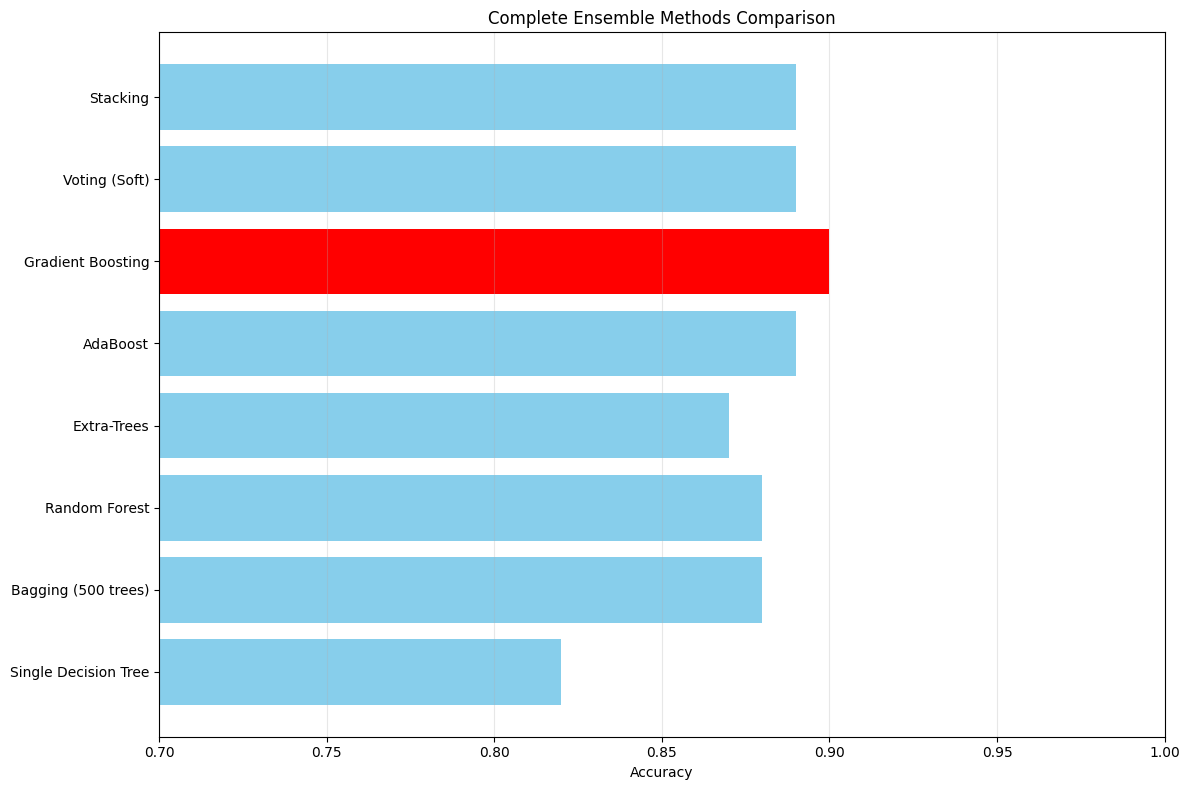


Best performing method: Gradient Boosting with accuracy 0.9000


In [34]:
# Train all classifiers including the new methods
classifiers = {
    'Single Decision Tree': DecisionTreeClassifier(random_state=42),
    'Bagging (500 trees)': BaggingClassifier(
        DecisionTreeClassifier(random_state=42),
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    'Extra-Trees': ExtraTreesClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=200,
        learning_rate=0.5,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        max_depth=2,
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),
    'Voting (Soft)': VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
            ('ada', AdaBoostClassifier(n_estimators=100, random_state=42))
        ],
        voting='soft'
    ),
    'Stacking': StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('extra', ExtraTreesClassifier(n_estimators=100, random_state=42)),
            ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
        ],
        final_estimator=LogisticRegression(),
        cv=3
    )
}

# Train and evaluate all classifiers
results = {}

print("\n" + "="*60)
print("COMPLETE ENSEMBLE METHODS COMPARISON")
print("="*60)

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name:25s}: {accuracy:.4f}")

print("="*60)

# Visualize comparison
plt.figure(figsize=(12, 8))
names = list(results.keys())
accuracies = list(results.values())
colors = ['red' if acc == max(accuracies) else 'skyblue' for acc in accuracies]

plt.barh(names, accuracies, color=colors)
plt.xlabel('Accuracy')
plt.title('Complete Ensemble Methods Comparison')
plt.xlim(0.7, 1.0)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

best_method = max(results, key=results.get)
print(f"\nBest performing method: {best_method} with accuracy {results[best_method]:.4f}")

## Key Takeaways

### Summary of Ensemble Methods

| Method | Parallelizable | Key Strength | Best Use Case |
|--------|----------------|--------------|---------------|
| **Voting** | Yes | Simple, combines diverse models | When you have different types of classifiers |
| **Bagging** | Yes | Reduces variance | High-variance models (like decision trees) |
| **Random Forest** | Yes | Powerful, provides feature importance | General-purpose classification/regression |
| **Extra-Trees** | Yes | Faster training than RF | When speed is important |
| **AdaBoost** | No | Focuses on hard examples | When you want to boost weak learners |
| **Gradient Boosting** | No | Highly accurate, corrects errors | When accuracy is critical |
| **Stacking** | Partially | Learns to combine models optimally | Competition-winning solutions |

### Important Principles

1. **Diversity is Crucial**: Ensemble methods work best when predictors are as independent as possible
2. **Bias-Variance Tradeoff**: 
   - Bagging reduces variance (good for high-variance models)
   - Boosting reduces bias (good for high-bias models)
3. **Parallelization**: 
   - Bagging/pasting methods can be fully parallelized
   - Boosting cannot be parallelized (sequential training)
   - Stacking can be partially parallelized (within layers)
4. **Regularization**:
   - For overfitting: reduce estimators, increase regularization, decrease learning rate
   - For underfitting: increase estimators, decrease regularization, increase learning rate

### Practical Tips

- **Start with Random Forest** - it's simple, powerful, and works well out-of-the-box
- **Use Gradient Boosting or XGBoost** for maximum accuracy (but tune carefully to avoid overfitting)
- **Try Voting Ensembles** to combine your best models with simple aggregation
- **Use Stacking** for competition-level performance (learns optimal combination)
- **Always use cross-validation** to select the best ensemble method for your problem
- **Monitor validation error** to find optimal hyperparameters and prevent overfitting
- **Use early stopping** with boosting methods to prevent overfitting
- **Consider Stochastic Gradient Boosting** (subsample < 1.0) for faster training and better generalization

### Overfitting vs Underfitting - What to Do

**For AdaBoost:**
- **Overfitting**: Reduce `n_estimators` or regularize base estimator more strongly
- **Underfitting**: Increase `n_estimators` or reduce regularization of base estimator

**For Gradient Boosting:**
- **Overfitting**: Decrease `learning_rate`, use early stopping, or increase `subsample`
- **Underfitting**: Increase `learning_rate` or `n_estimators`

**For Speed:**
- Use bagging/pasting (parallelizable across multiple servers)
- Use Extra-Trees (faster than Random Forests)
- Use `subsample < 1.0` in Gradient Boosting (Stochastic GB)
- Use `n_jobs=-1` to leverage all CPU cores

**For Best Results:**
- Combine diverse algorithms in voting ensemble
- Use soft voting when classifiers provide probability estimates
- Consider stacking for competition-level performance
- Always validate with cross-validation

## Exercises

Here are some exercises to test your understanding:

1. **If you have trained five different models on the exact same training data, and they all achieve 95% precision, is there any chance that you can combine these models to get better results? If so, how? If not, why?**

2. **What is the difference between hard and soft voting classifiers?**

3. **Is it possible to speed up training of a bagging ensemble by distributing it across multiple servers? What about pasting ensembles, boosting ensembles, Random Forests, or stacking ensembles?**

4. **What is the benefit of out-of-bag evaluation?**

5. **What makes Extra-Trees more random than regular Random Forests? How can this extra randomness help? Are Extra-Trees slower or faster than regular Random Forests?**

6. **If your AdaBoost ensemble underfits the training data, which hyperparameters should you tweak and how?**

7. **If your Gradient Boosting ensemble overfits the training set, should you increase or decrease the learning rate?**

### Practical Exercise 1: MNIST Ensemble

**Challenge:** Load the MNIST data, split it into training (50,000), validation (10,000), and test (10,000) sets. Then:
1. Train various classifiers (Random Forest, Extra-Trees, SVM)
2. Combine them into an ensemble that outperforms each individual classifier
3. Use soft or hard voting
4. Evaluate on the test set

### Practical Exercise 2: Stacking on MNIST

**Challenge:** 
1. Use the individual classifiers from Exercise 1 to make predictions on the validation set
2. Create a new training set with these predictions as features
3. Train a blender on this new training set
4. Evaluate the stacking ensemble on the test set
5. Compare with the voting classifier

### Quick Practice Exercises

Try modifying the code above to:
- Load a different dataset (e.g., digits, wine, breast cancer from sklearn)
- Experiment with different hyperparameters
- Create your own voting ensemble with different base classifiers
- Implement your own stacking ensemble manually
- Try XGBoost with different hyperparameters

## Congratulations! 🎉

You've completed the comprehensive tutorial on Ensemble Learning! You now understand:

✅ How voting classifiers combine different models (hard and soft voting)  
✅ The power of bagging and pasting for reducing variance  
✅ Random Forests and their feature importance capabilities  
✅ Extra-Trees and how they trade bias for variance  
✅ Random Patches and Random Subspaces for feature sampling  
✅ Out-of-Bag evaluation for model validation  
✅ AdaBoost and how it focuses on hard examples  
✅ Gradient Boosting and residual error correction  
✅ Early stopping techniques (staged_predict and warm_start)  
✅ Stochastic Gradient Boosting with subsampling  
✅ XGBoost for high-performance gradient boosting  
✅ Stacking ensembles and meta-learning  
✅ When to use each ensemble method  
✅ How to tune and evaluate ensemble models  

### What You've Learned

**Core Concepts:**
- Ensemble methods combine multiple predictors to create stronger models
- Diversity among predictors is crucial for ensemble success
- Different ensemble methods address different aspects of the bias-variance tradeoff

**Methods Covered:**
1. **Voting** - Simple aggregation of diverse models
2. **Bagging/Pasting** - Training on random subsets to reduce variance
3. **Random Forests** - Bagging + random feature selection
4. **Extra-Trees** - Even more randomness for faster training
5. **AdaBoost** - Sequential training with instance reweighting
6. **Gradient Boosting** - Sequential training on residual errors
7. **XGBoost** - Optimized, scalable gradient boosting
8. **Stacking** - Learning to optimally combine models

Ensemble methods are among the most powerful tools in machine learning. Random Forests, Gradient Boosting, and XGBoost consistently win competitions and excel on real-world problems!

**Next Steps:**
- Practice with the exercises above
- Try these methods on your own datasets
- Experiment with hyperparameter tuning using GridSearchCV or RandomizedSearchCV
- Explore XGBoost and LightGBM for production-grade gradient boosting
- Learn about CatBoost for handling categorical features
- Study competition-winning solutions on Kaggle to see stacking in action
- Implement your own ensemble methods from scratch for deeper understanding

**Resources:**
- Scikit-learn documentation on ensemble methods
- XGBoost documentation and tutorials
- Kaggle competitions to see ensembles in action
- Research papers on boosting and stacking techniques

Happy ensembling! 🚀